In [ ]:
# Import library dasar
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import CSVLogger
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Bersihkan session
tf.keras.backend.clear_session()

# Set random seed
seed_value = 42
os.environ["PYTHONHASHSEED"] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

print("Initial setup completed. Seed has been fixed.")

Initial setup completed. Seed has been fixed.


In [ ]:
print("Downloading dataset")

!pip install gdown -q
!gdown 1b67VYi8SuLv8ru8oFNC9ZqZBLynZ4F3V -O dataset_split_224.zip

print("Extracting dataset")

# Hapus folder lama jika ada
!rm -rf dataset_siap_pakai

# Extract dataset
!unzip -q dataset_split_224.zip -d dataset_siap_pakai

print("Dataset extracted successfully.")

Downloading...
From: https://drive.google.com/uc?id=1b67VYi8SuLv8ru8oFNC9ZqZBLynZ4F3V
To: /content/dataset_split_224.zip
100% 19.4M/19.4M [00:00<00:00, 158MB/s]
Extracting dataset
Dataset extracted successfully.


In [ ]:
# Cek struktur folder dataset
for root, dirs, files in os.walk("dataset_siap_pakai"):
    level = root.replace("dataset_siap_pakai", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")

    if level < 3:
        for f in files[:5]:
            print(f"{indent}  {f}")

dataset_siap_pakai/
  train/
    AI/
      filippo-nassetti-ai-designs-spaceships-bosch-caravaggio-designboom-600.jpg
      GettyImages-1096829784-copy.jpg
      image33.jpg
      Blogs.jpg
      psychedelic-image-edited-2.png
    Real/
      HD-wallpaper-scenery-lake-nature-sky-tree-water.jpg
      Portrait-Photographers-Yousuf-Karsh-King.jpg
      7ce6zbax23_WEB_257649.jpg
      set-safari-animals-illustration-600nw-2150029883.jpg
      02-still-for-america-room-loop-superJumbo.jpg
  test/
    AI/
      1440_AI_and_animal_language_feat.jpg
      335893730_1248848252414001_2214479283759117231_n_1679724354609_1679724368314_1679724368314.jpg
      sddefault.jpg
      tp-composite-ai-art-new.jpg
      1588269690157-Screen-Shot-2020-04-30-at-20037-PM.png
    Real/
      people-pleasing_mask.jpg
      147660_1.jpg
      image16.jpeg
      1200px-Claude_Monet2C_Impression2C_soleil_levant.jpg
      sddefault.jpg
  val/
    AI/
      ai-art-prompt-8.png
      wp-image-940-16849365973x2.jpg
  

In [ ]:
# Pengaturan dataset
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Loading training data")
train_dataset_raw = image_dataset_from_directory(
    "dataset_siap_pakai/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=seed_value
)

# Simpan class names sebelum prefetch
class_names = train_dataset_raw.class_names
print("Class names:", class_names)

print("\nLoading validation data")
val_dataset_raw = image_dataset_from_directory(
    "dataset_siap_pakai/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("\nLoading testing data")
test_dataset_raw = image_dataset_from_directory(
    "dataset_siap_pakai/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Datasets loaded successfully.")

Loading training data
Found 606 files belonging to 2 classes.
Class names: ['AI', 'Real']

Loading validation data
Found 129 files belonging to 2 classes.

Loading testing data
Found 131 files belonging to 2 classes.
Datasets loaded successfully.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset_raw.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset_raw.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset_raw.prefetch(buffer_size=AUTOTUNE)

print("Dataset pipeline optimized successfully.")

Dataset pipeline optimized successfully.


In [ ]:
def build_efficientnet_aug_model():
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal", seed=seed_value),
        layers.RandomRotation(0.05, seed=seed_value),
        layers.RandomTranslation(0.05, 0.05, seed=seed_value),
        layers.RandomZoom(0.05, seed=seed_value),
        layers.RandomContrast(0.1, seed=seed_value),
        layers.RandomBrightness(0.05, value_range=(0.0, 255.0), seed=seed_value)
    ], name="data_augmentation")

    base_model = EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.3, seed=seed_value),
        layers.Dense(1, activation="sigmoid")
    ])

    return model

model_effnet_aug = build_efficientnet_aug_model()
model_effnet_aug.summary()

print("EfficientNetB0 with refined subtle augmentation model built successfully.")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,972 (15.47 MB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

EfficientNetB0 with refined subtle augmentation model built successfully.


In [ ]:
# Pengaturan training
EPOCHS = 20
LEARNING_RATE = 0.001

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

metrics = [
    "accuracy",
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall")
]

# Compile model
model_effnet_aug.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=metrics
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
# Simpan history training ke CSV
csv_logger = CSVLogger("history_efficientnetb0_aug_scen2.csv", append=False)

print("Starting training for EfficientNetB0 with augmentation")

history_scen2 = model_effnet_aug.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[csv_logger]
)

print("Training completed.")
print("Training history saved successfully.")

Starting training for EfficientNetB0 with augmentation
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 324ms/step - accuracy: 0.5611 - loss: 0.8883 - precision: 0.5658 - recall: 0.5248 - val_accuracy: 0.5891 - val_loss: 0.6674 - val_precision: 0.8000 - val_recall: 0.2462
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.6634 - loss: 0.6678 - precision: 0.6634 - recall: 0.6634 - val_accuracy: 0.6357 - val_loss: 0.6249 - val_precision: 0.8214 - val_recall: 0.3538
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.7195 - loss: 0.5881 - precision: 0.7138 - recall: 0.7327 - val_accuracy: 0.6899 - val_loss: 0.6040 - val_precision: 0.8571 - val_recall: 0.4615
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.7558 - loss: 0.5455 - precision: 0.7508 - recall: 0.7657 - val_accuracy: 0.7364 - val_loss: 0.5812 - val_precision: 0.8605 - val_recall: 0.5692
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.7558 - loss: 0.5221 - precision: 0.7609 

In [ ]:
test_loss, test_accuracy, test_precision, test_recall = model_effnet_aug.evaluate(test_dataset)

if (test_precision + test_recall) == 0:
    test_f1 = 0
else:
    test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)

print("Test evaluation completed.")
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")
print(f"Test F1-Score  : {test_f1:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.8626 - loss: 0.3601 - precision: 0.8750 - recall: 0.8485
Test evaluation completed.
Test Loss      : 0.3601
Test Accuracy  : 0.8626
Test Precision : 0.8750
Test Recall    : 0.8485
Test F1-Score  : 0.8615


In [ ]:
print("Generating predictions on test data")

y_true = np.concatenate([y.numpy() for x, y in test_dataset], axis=0).flatten().astype(int)

y_pred_probs = model_effnet_aug.predict(test_dataset)
y_pred = (y_pred_probs >= 0.5).astype("int32").flatten()

print("Prediction results generated successfully.")
print("Class names:", class_names)

Generating predictions on test data
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 589ms/step
Prediction results generated successfully.
Class names: ['AI', 'Real']


In [ ]:
y_true
y_pred
y_pred_probs
class_names

['AI', 'Real']

In [ ]:
print("EfficientNetB0 with Augmentation Classification Report")

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()
display(df_report)

print("Classification report displayed successfully.")

EfficientNetB0 with Augmentation Classification Report


,precision,recall,f1-score,support
AI,0.850746,0.876923,0.863636,65.000000
Real,0.875000,0.848485,0.861538,66.000000
accuracy,0.862595,0.862595,0.862595,0.862595
macro avg,0.862873,0.862704,0.862587,131.000000
weighted avg,0.862966,0.862595,0.862579,131.000000


Classification report displayed successfully.


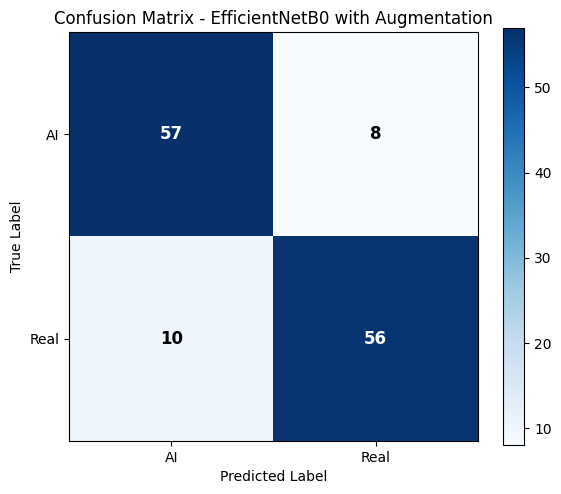

Confusion matrix image saved successfully.


In [ ]:
# Membuat confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - EfficientNetB0 with Augmentation")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=12,
            fontweight="bold"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("heatmap_efficientnetb0_aug_scen2.png", dpi=300)
plt.show()

print("Confusion matrix image saved successfully.")

Membuat grafik Accuracy dan Loss


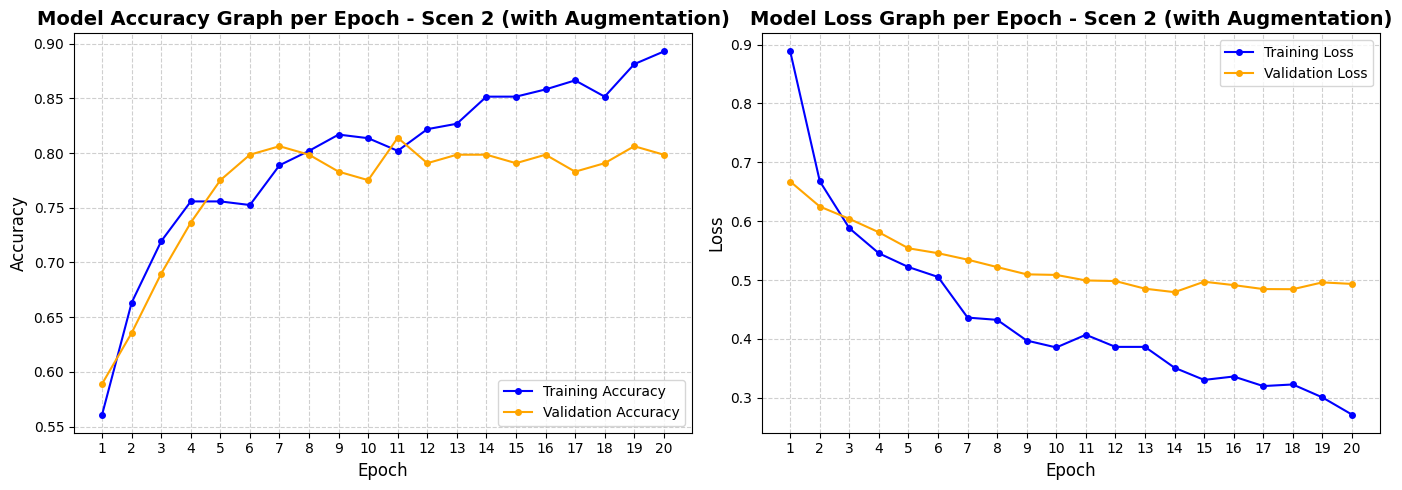

In [ ]:
# Visualisasi Grafik Accuracy dan Loss
import pandas as pd
import matplotlib.pyplot as plt

print("Membuat grafik Accuracy dan Loss")

# Membaca data history dari file CSV
history_df = pd.read_csv("history_efficientnetb0_aug_scen2.csv")

epochs = history_df['epoch'] + 1

plt.figure(figsize=(14, 5))

# Grafik 1: Akurasi (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs, history_df['accuracy'], label='Training Accuracy', color='blue', marker='o', markersize=4)
plt.plot(epochs, history_df['val_accuracy'], label='Validation Accuracy', color='orange', marker='o', markersize=4)
plt.title('Model Accuracy Graph per Epoch - Scen 2 (with Augmentation)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(epochs)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Grafik 2: Kehilangan (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs, history_df['loss'], label='Training Loss', color='blue', marker='o', markersize=4)
plt.plot(epochs, history_df['val_loss'], label='Validation Loss', color='orange', marker='o', markersize=4)
plt.title('Model Loss Graph per Epoch - Scen 2 (with Augmentation)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("grafik_akurasi_loss_scen2.png", dpi=300)
plt.show()

Finding misclassified images...
Total misclassified images: 18


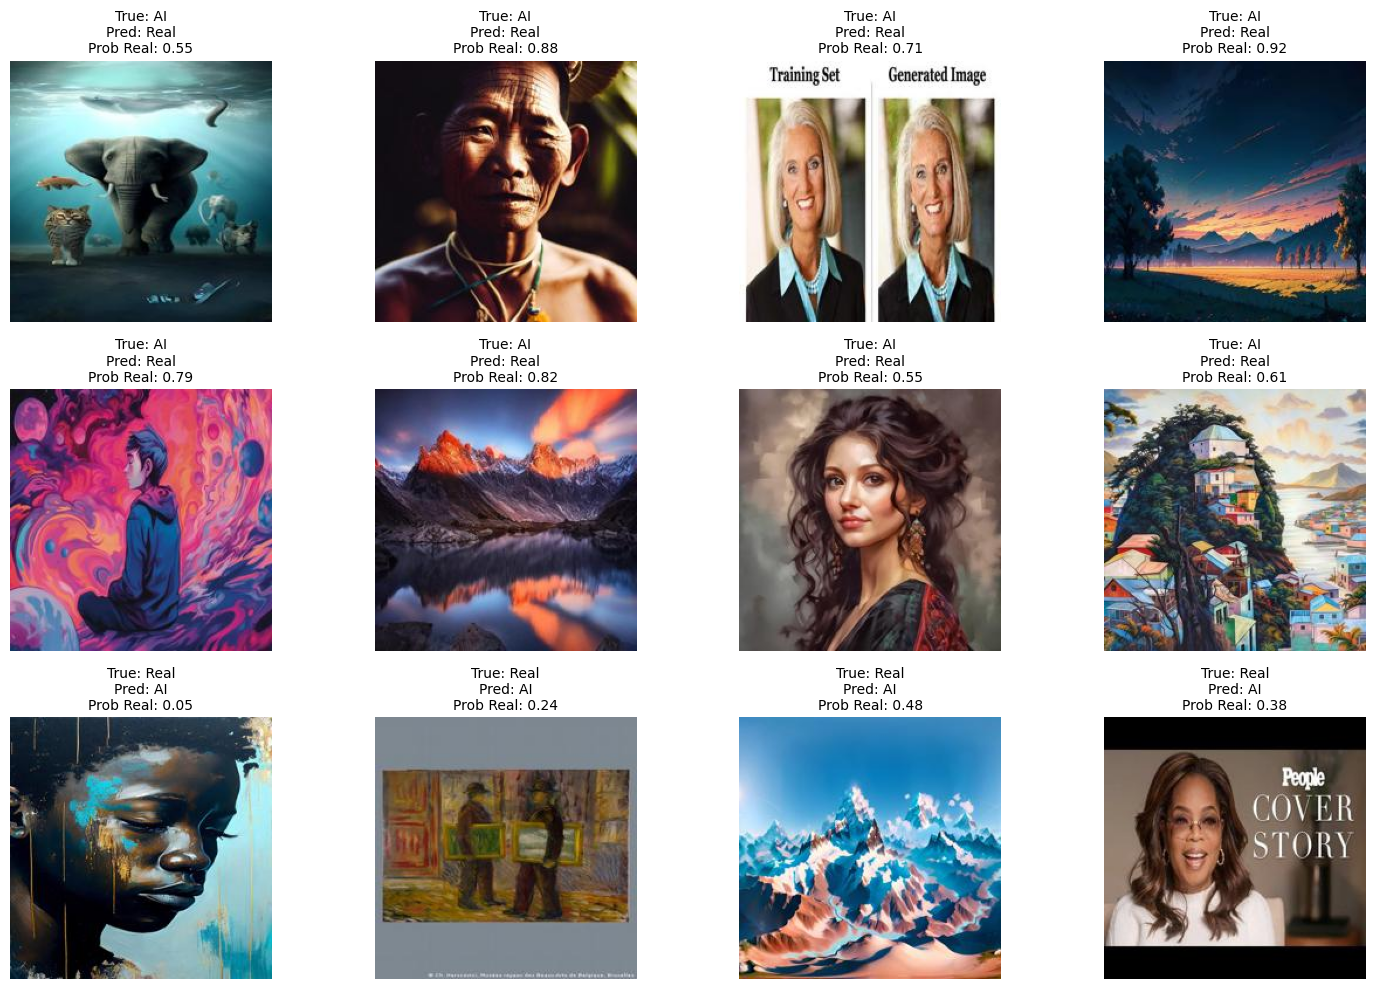

Misclassified images displayed and saved successfully.


In [ ]:
# Menampilkan beberapa gambar yang salah diprediksi oleh model
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

print("Finding misclassified images...")

# Ambil path gambar test sesuai urutan dataset
try:
    test_file_paths = test_dataset_raw.file_paths
except:
    test_file_paths = []
    for class_name in class_names:
        class_dir = os.path.join("dataset_siap_pakai/test", class_name)
        files = sorted(os.listdir(class_dir))
        for file in files:
            test_file_paths.append(os.path.join(class_dir, file))

wrong_indices = np.where(y_true != y_pred)[0]

print(f"Total misclassified images: {len(wrong_indices)}")

num_images = min(12, len(wrong_indices))

plt.figure(figsize=(15, 10))

for i, idx in enumerate(wrong_indices[:num_images]):
    img_path = test_file_paths[idx]
    img = Image.open(img_path).convert("RGB")

    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    prob_real = y_pred_probs[idx][0]

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"True: {true_label}\nPred: {pred_label}\nProb Real: {prob_real:.2f}",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("misclassified_images_efficientnetb0_aug_scen2.png", dpi=300)
plt.show()

print("Misclassified images displayed and saved successfully.")